In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

In [5]:
# Create non-linear dataset
X, y = make_moons(n_samples=500, noise=0.25, random_state=42)

# Split & scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
# Plot a activation function
def plot_activation(func,name,x_range=(-5,5)):
    x = np.linspace(*x_range,200)
    y = func(x)
    plt.figure(figsize=(5,4))
    plt.plot(x,y)
    plt.title(f"{name} Activation")
    plt.grid(True)
    plt.show()

In [26]:
def train_and_plot(activation, act_name):
    model = MLPClassifier(
        hidden_layer_sizes=(8,),
        activation=activation,
        solver='adam',
        max_iter=1000,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    # Decision boundary
    h = .02
    xx, yy = np.meshgrid(
        np.arange(X_train[:, 0].min() - 1, X_train[:, 0].max() + 1, h),
        np.arange(X_train[:, 1].min() - 1, X_train[:, 1].max() + 1, h)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(5, 4))
    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=20, edgecolor='k')
    plt.title(f"{act_name} - Accuracy: {acc:.2f}")
    plt.show()

    return acc

# Linear Activation Function

In [3]:
def linear(x):
  return x

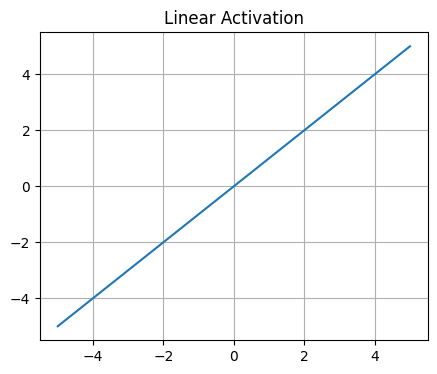

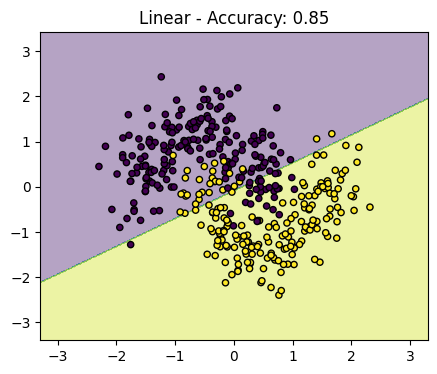

In [27]:
results = {}
plot_activation(linear,"Linear")
results["Linear"] = train_and_plot("identity","Linear")

- Even after 8 neurons in the hidden layers we were not able to classify properly because of **linear activation functin**

In [18]:
import numpy as np

x = np.array([1,2,3])
y = np.array([4,5])

xx, yy = np.meshgrid(x, y)

print(xx)
print(yy)

[[1 2 3]
 [1 2 3]]
[[4 4 4]
 [5 5 5]]


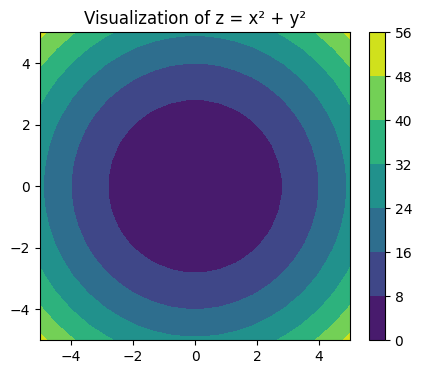

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# create x and y ranges
x = np.linspace(-5, 5, 20)
y = np.linspace(-5, 5, 20)

# create grid
xx, yy = np.meshgrid(x, y)

# function evaluated on grid
z = xx**2 + yy**2

plt.figure(figsize=(5,4))
plt.contourf(xx, yy, z)
plt.colorbar()
plt.title("Visualization of z = x² + y²")
plt.show()

What happens

x → horizontal coordinates

y → vertical coordinates

meshgrid → creates all combinations of (x,y)

z = f(x,y) is computed for every point

Conceptually the grid looks like:

- (x1,y1) (x2,y1) (x3,y1)
- (x1,y2) (x2,y2) (x3,y2)
- (x1,y3) (x2,y3) (x3,y3)

# Sigmoid Activation Function

In [22]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

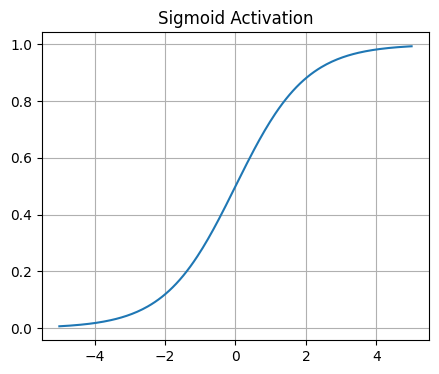

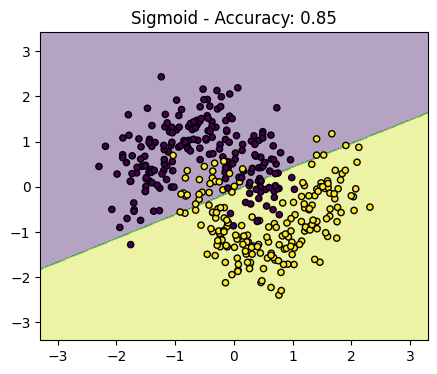

In [25]:
plot_activation(sigmoid,"Sigmoid")
results["Sigmoid"] = train_and_plot("logistic","Sigmoid")

# Tanh Activation

In [28]:
def tanh_fn(x):
    return np.tanh(x)

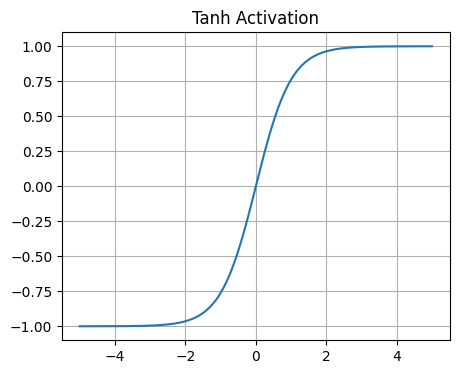

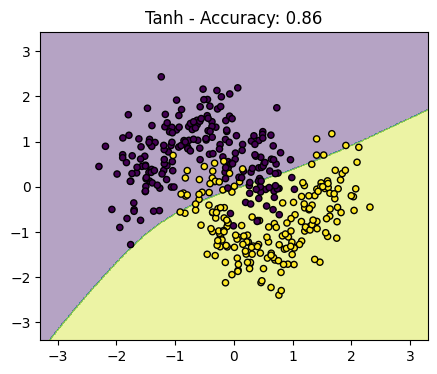

In [29]:
plot_activation(tanh_fn,"Tanh")
results["Tanh"] = train_and_plot("tanh","Tanh")

In [30]:
results

{'Linear': 0.85, 'Tanh': 0.86}

# Vanishing Gradient

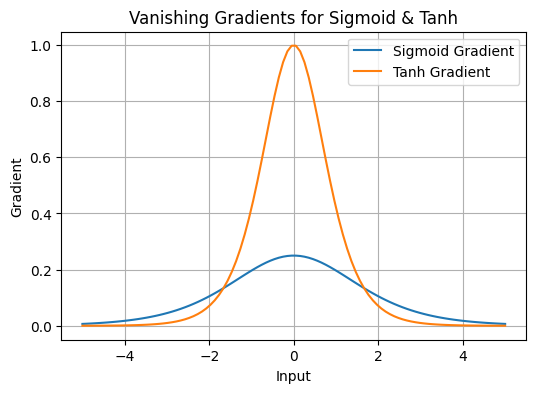

In [31]:
# Simulate gradient shrinkage in deep sigmoid network
x = np.linspace(-5, 5, 100)

grad_sigmoid = sigmoid(x) * (1 - sigmoid(x))
grad_tanh = 1 - np.tanh(x)**2

plt.figure(figsize=(6,4))
plt.plot(x, grad_sigmoid, label='Sigmoid Gradient')
plt.plot(x, grad_tanh, label='Tanh Gradient')

plt.title("Vanishing Gradients for Sigmoid & Tanh")
plt.xlabel("Input")
plt.ylabel("Gradient")

plt.legend()
plt.grid(True)
plt.show()

In [33]:
print(np.tanh(2))

0.9640275800758169


In [34]:
print(sigmoid(2))

0.8807970779778823
